In [145]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from scipy.optimize import fmin_cobyla
import numpy as np
import h5py
from sklearn.model_selection import GridSearchCV
from astroML.utils import split_samples
from astroML.utils import completeness_contamination 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve
from astropy.visualization import hist
import astropy
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier

- `mtot`: the total mass of the binary
- `q`: the mass ratio
- `chi1x`, `chi1y`, `chi1z`, `chi2x`, `chi2y`, `chi2z`: the components of the black-hole spins in a suitable reference frame.
- `ra`, `dec`: the location of the source in the sky
- `iota`: the inclination of the orbital plane'
- `psi`: the polarization angle (gravitational waves have two polarization states much like light)
- `z`: the redshift

In [148]:
data = h5py.File("sample_2e7_design_precessing_higherordermodes_3detectors.h5", 'r')

In [150]:
print("Keys:", list(data.keys()))

Keys: ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']


In [152]:
det = data["det"] #this determine the detectability of the system

In [154]:
#Keys: ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']
#this is for the first bh
chi1x = data["chi1x"]
chi1y = data["chi1y"]
chi1z = data["chi1z"]

#this is for the second bh
chi2x = data["chi2x"]
chi2y = data["chi2y"]
chi2z = data["chi2z"]

#ra, dec coordinate in the sky 
ra = data["ra"]
dec = data["dec"]

iota = data["iota"]
mtot = data["mtot"]
psi = data["psi"]
q = data["q"]
snr = data["snr"] 
z = data["z"]

print(len(z))

20000000


In [156]:
#take one every 100 points
X = np.column_stack([chi1x[::100], chi1y[::100], chi1z[::100],
                    chi2x[::100], chi2y[::100], chi2z[::100],
                    ra[::100], dec[::100], iota[::100],
                    mtot[::100], psi[::100], q[::100], z[::100]])

Y = det[::100]

#take the first 100000
number_data =int(1e5)
X = np.column_stack([chi1x[:number_data], chi1y[:number_data], chi1z[:number_data],
                    chi2x[:number_data], chi2y[:number_data], chi2z[:number_data],
                    ra[:number_data], dec[:number_data], iota[:number_data],
                    mtot[:number_data], psi[:number_data], q[:number_data], z[:number_data]])

Y = det[:number_data]

In [158]:
(X_train, X_test), (y_train, y_test) = split_samples(X, Y, [0.80, 0.20], random_state=0) 

In [159]:
print(len(X_train))
print(len(y_train))

160000
160000


[0 0 0 ... 0 0 0]
[5.68350845e-05 2.30047303e-03 8.62610557e-06 ... 4.85033849e-04
 2.61262123e-08 1.75513559e-03]


C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\User\AppData\Local\Temp\ipykernel_16928\3838365989.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


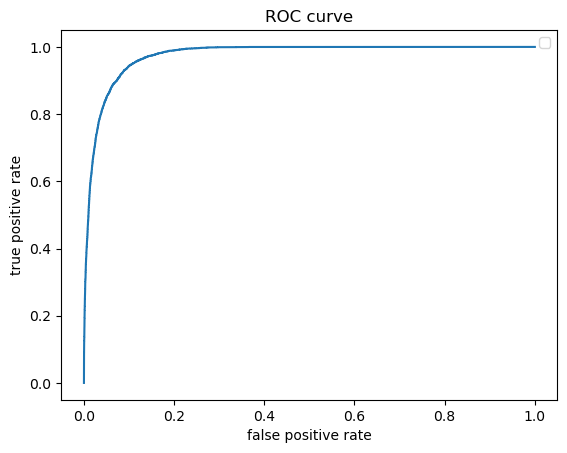

In [160]:
clf = LogisticRegression(class_weight = "balanced")
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test) [:,1] 
print(y_pred)
print(y_prob)

fpr, tpr, thresh = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.title("ROC curve")
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.legend()

In [161]:
completeness, contamination = completeness_contamination(y_pred, y_test)
print(completeness)
print(contamination)

0.9460976024485632
0.38668430335097004


### Logistic Regression 

In [163]:
print(X_train[:,0])

[ 0.36574782  0.10793583 -0.22236393 ... -0.28386491 -0.52969674
 -0.27339233]


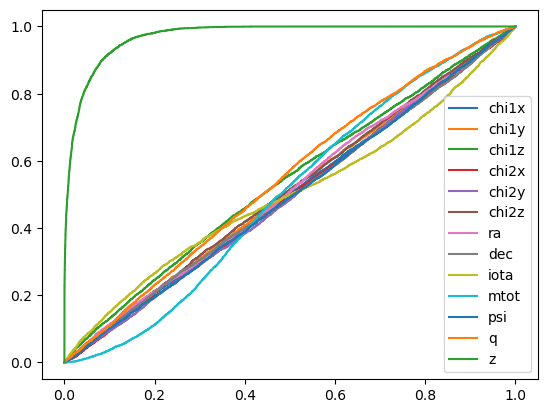

In [164]:
lab = ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'ra', 'dec', 'iota', 'mtot', 'psi', 'q', 'z']

X = np.column_stack([chi1x[::100], chi1y[::100], chi1z[::100],
                    chi2x[::100], chi2y[::100], chi2z[::100],
                    ra[::100], dec[::100], iota[::100],
                    mtot[::100], psi[::100], q[::100], z[::100]])

Y = det[::100]

for n,l in zip(range(13),lab):
    clf = LogisticRegression(class_weight='balanced')
    clf.fit(X_train[:,n][:, np.newaxis], y_train)
    y_pred = clf.predict(X_test[:,n][:, np.newaxis])
    y_prob = clf.predict_proba(X_test[:,n][:, np.newaxis]) [:,1]
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=l)

plt.legend()

In [165]:
X_train[:,0:1]

array([[ 0.36574782],
       [ 0.10793583],
       [-0.22236393],
       ...,
       [-0.28386491],
       [-0.52969674],
       [-0.27339233]])

In [166]:
print(X.shape[1])
#X_train[:,0:i+1]

13


C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i 

Text(0, 0.5, 'true positive rate')

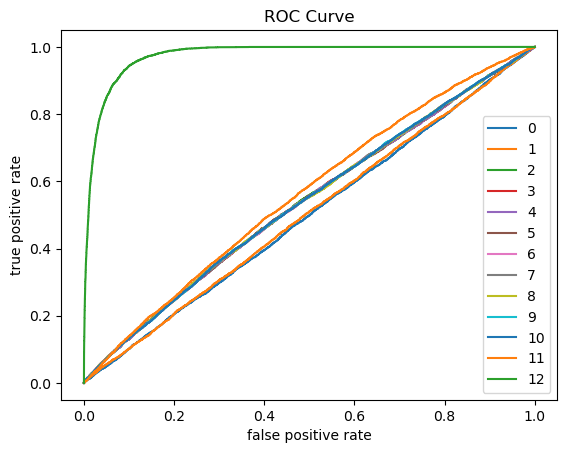

In [167]:
for n in range(13):
    
    clf = LogisticRegression(class_weight='balanced')
    clf.fit(X_train[:, 0:n+1], y_train)

    y_pred = clf.predict(X_test[:, 0:n+1])
    y_prob = clf.predict_proba(X_test[:, 0:n+1]) [:,1]
    
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label= n)

plt.title("ROC Curve")
plt.legend()
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')

[[32855  1264]
 [ 1302  4579]]


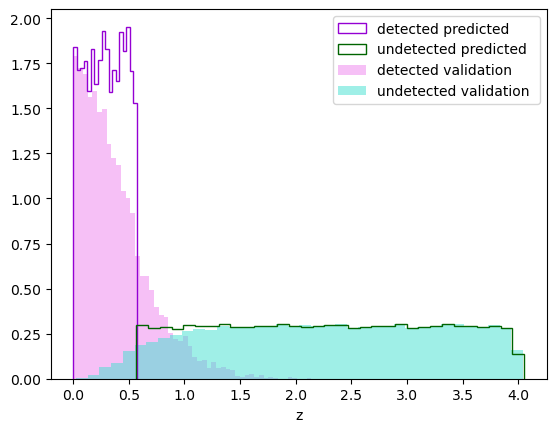

In [168]:
clf=LogisticRegression()
clf.fit(X_train[:,12].reshape(-1,1),y_train)
y_pred = clf.predict(X_test[:,12].reshape(-1,1))

astropy.visualization.hist(X_test[:,12][y_pred==1],bins="freedman", histtype="step", color="darkviolet", density=True, label="detected predicted")
astropy.visualization.hist(X_test[:,12][y_pred==0],bins="freedman", histtype="step", color="darkgreen", density=True, label="undetected predicted")

astropy.visualization.hist(X_test[:,12][y_test==1],bins="freedman", density=True, alpha=0.5, color= "violet", label="detected validation")
astropy.visualization.hist(X_test[:,12][y_test==0],bins="freedman", density=True, alpha=0.5, color="turquoise", label="undetected validation ")



plt.legend()
plt.xlabel("z")

print(confusion_matrix(y_test, y_pred))

### Decision tree 

In [170]:
clf1 = DecisionTreeClassifier(random_state=0, max_depth=10,criterion='entropy')
clf1.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=0)

[0 0 0 ... 0 0 0]
[0. 0. 0. ... 0. 0. 0.]


C:\Users\User\AppData\Local\Temp\ipykernel_16928\1767335996.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


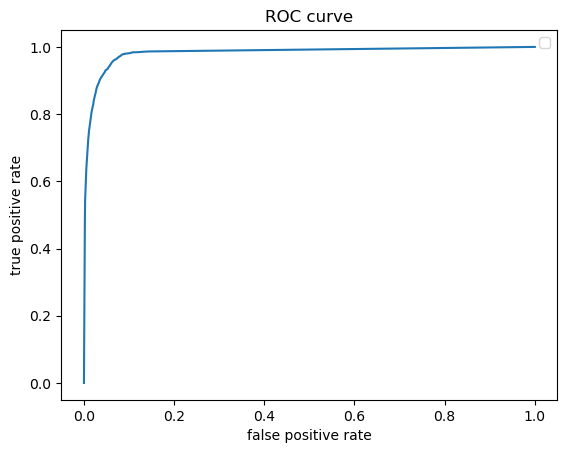

In [171]:
y_pred = clf1.predict(X_test)
y_prob = clf1.predict_proba(X_test) [:,1] 
print(y_pred)
print(y_prob)

fpr, tpr, thresh = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.title("ROC curve")
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.legend()

In [172]:
completeness_test = []
contamination_test = []
completeness_train = []
contamination_train = []

d_values = np.arange(1,15)
for depth in d_values:
    clf = DecisionTreeClassifier(random_state=1, max_depth=depth,criterion='entropy')
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    C = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = C.ravel()
    completeness_test.append(tp/(tp+fn))
    contamination_test.append(fp/(tp+fp))

    y_pred = clf.predict(X_train)
    C = confusion_matrix(y_train, y_pred)
    tn, fp, fn, tp = C.ravel()
    completeness_train.append(tp/(tp+fn))
    contamination_train.append(fp/(tp+fp))
    

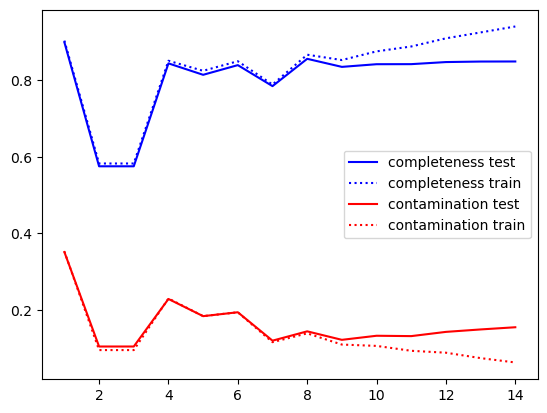

In [173]:
plt.plot(d_values,completeness_test,label='completeness test',color='blue')
plt.plot(d_values,completeness_train,label='completeness train',color='blue',ls='dotted')

plt.plot(d_values,contamination_test,label='contamination test',color='red')
plt.plot(d_values,contamination_train,label='contamination train',color='red',ls='dotted')
plt.legend()

Text(0, 0.5, 'true positive rate')

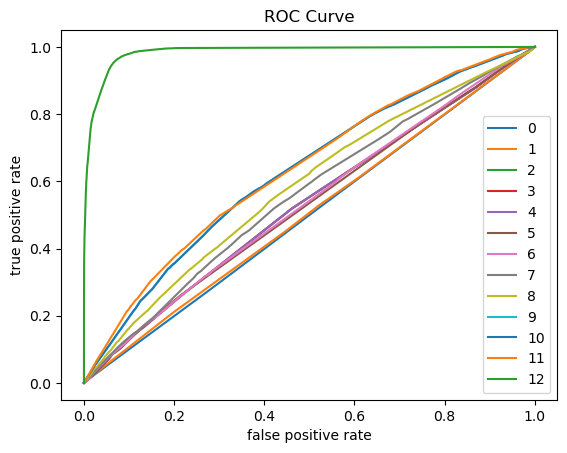

In [174]:
for n in range(13):
    
    clf1 = DecisionTreeClassifier(random_state=0, max_depth=7,criterion='entropy')
    clf1.fit(X_train[:, 0:n+1], y_train)

    y_pred = clf1.predict(X_test[:, 0:n+1])
    y_prob = clf1.predict_proba(X_test[:, 0:n+1]) [:,1]
    
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label= n)

plt.title("ROC Curve")
plt.legend()
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')

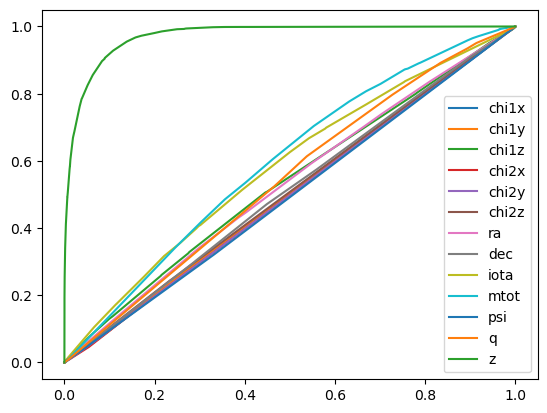

In [175]:
lab = ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'ra', 'dec', 'iota', 'mtot', 'psi', 'q', 'z']

X = np.column_stack([chi1x[::100], chi1y[::100], chi1z[::100],
                    chi2x[::100], chi2y[::100], chi2z[::100],
                    ra[::100], dec[::100], iota[::100],
                    mtot[::100], psi[::100], q[::100], z[::100]])

Y = det[::100]

for n,l in zip(range(13),lab):
    clf1 = DecisionTreeClassifier(random_state=0, max_depth=7,criterion='entropy')
    clf1.fit(X_train[:,n][:, np.newaxis], y_train)
    y_pred = clf1.predict(X_test[:,n][:, np.newaxis])
    y_prob = clf1.predict_proba(X_test[:,n][:, np.newaxis]) [:,1]
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=l)
    
    comp, cont = completeness_contamination(y_test, y_pred)
    

plt.legend()

[[32968  1151]
 [ 1405  4476]]


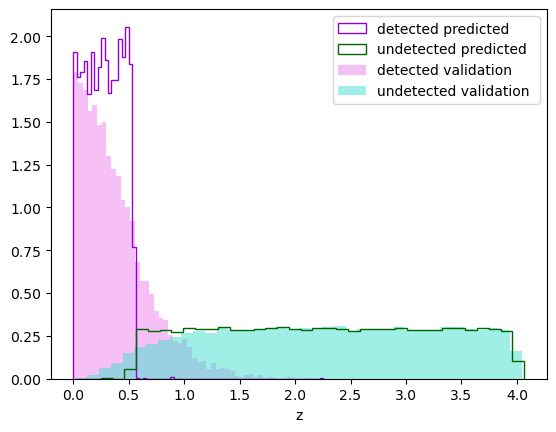

In [176]:
clf1 = DecisionTreeClassifier(random_state=0, max_depth=7,criterion='entropy')
clf1.fit(X_train[:,12].reshape(-1,1),y_train)
y_pred = clf1.predict(X_test[:,12].reshape(-1,1))

astropy.visualization.hist(X_test[:,12][y_pred==1],bins="freedman", histtype="step", color="darkviolet", density=True, label="detected predicted")
astropy.visualization.hist(X_test[:,12][y_pred==0],bins="freedman", histtype="step", color="darkgreen", density=True, label="undetected predicted")

astropy.visualization.hist(X_test[:,12][y_test==1],bins="freedman", density=True, alpha=0.5, color= "violet", label="detected validation")
astropy.visualization.hist(X_test[:,12][y_test==0],bins="freedman", density=True, alpha=0.5, color="turquoise", label="undetected validation ")



plt.legend()
plt.xlabel("z")

print(confusion_matrix(y_test, y_pred))